In [5]:
import os
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import Dataset
import torch.nn as nn
import numpy as np
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.append('../')

import torchvision.transforms.functional as F

In [9]:
img = torch.rand(4, 3, 5, 7)
d = torch.rand(4, 1, 5, 7)

In [9]:
class Randomizer():
    def __init__(self, p, transform):
        self.p = p
        self.transform = transform

    def __call__(self, img):
        if np.random.binomial(1, p=self.p):
            return self.transform(img)
        return img

class MultiHorizontalFlip():
    def __init__(self, p):
        self.p = p

    def __call__(self, img):
        if self.flip:
            return F.hflip(img)
        else:
            return img

    def set_param(self):
        if np.random.binomial(1, p=self.p):
            self.flip = True
        else:
            self.flip = False


class MultiVerticalFlip():
    def __init__(self, p):
        self.p = p

    def __call__(self, img, **kwargs):
        if self.flip:
            return F.vflip(img)
        else:
            return img

    def set_param(self):
        if np.random.binomial(1, p=self.p):
            self.flip = True
        else:
            self.flip = False

class MultiHorizontalFlip():
    def __init__(self, p):
        self.p = p

    def __call__(self, img, **kwargs):
        if self.flip:
            return F.hflip(img)
        else:
            return img

    def set_param(self):
        if np.random.binomial(1, p=self.p):
            self.flip = True
        else:
            self.flip = False

class MultiRandomRotate():
    def __init__(self, angle):
        self.max_angle = angle
        self.expand=False
        self.center=None
        self.interpolation=transforms.InterpolationMode.NEAREST
        self.fill_values = {
            'rgb': -1,
            'semantic': 255,
            'depth': 0
        }

    def __call__(self, img, modality, **kwargs):
        fill_value = self.fill_values[modality]
        return F.rotate(img, self.cur_angle, self.interpolation, self.expand, self.center, fill_value)

    def set_param(self):
        self.cur_angle = np.random.uniform(0, self.max_angle)

class DepthNormalizer():
    def __init__(self):
        pass

    def __call__(self, img):
        img = img.float() / (2**15 - 1)
        return img 


# rotator = Randomizer(p=1, transform=transforms.RandomRotation(degrees=90, fill=255))
# horizontal = transforms.RandomHorizontalFlip(p=0.5)
# vertical = transforms.RandomVerticalFlip(p=0.5)
# normalizer = transforms.Normalize(mean=[121.1943975,  120.18005528, 118.44828826], std=[23.01586477, 22.23779258, 22.15062455])

In [16]:
0xB0BA_C_3AB0DA

12144762073306

In [12]:
normalizer(img).size()

torch.Size([4, 3, 5, 7])

In [10]:
depth = Image.open('/home/data/dq/clevr_complex/train/depth/1002_0.png')


In [11]:
DepthNormalizer()(transforms.ToTensor()(depth)).min()

tensor(0.2095)

In [82]:
DepthNormalizer()(transforms.ToTensor()(depth))[0][-10:, :10]

tensor([[0.2294, 0.2293, 0.2291, 0.2290, 0.2289, 0.2287, 0.2286, 0.2285, 0.2283,
         0.2282],
        [0.2291, 0.2290, 0.2288, 0.2287, 0.2286, 0.2284, 0.2283, 0.2282, 0.2281,
         0.2279],
        [0.2288, 0.2287, 0.2286, 0.2284, 0.2283, 0.2282, 0.2280, 0.2279, 0.2278,
         0.2276],
        [0.2285, 0.2284, 0.2283, 0.2281, 0.2280, 0.2279, 0.2277, 0.2276, 0.2275,
         0.2274],
        [0.2282, 0.2281, 0.2280, 0.2279, 0.2277, 0.2276, 0.2275, 0.2273, 0.2272,
         0.2271],
        [0.2280, 0.2278, 0.2277, 0.2276, 0.2274, 0.2273, 0.2272, 0.2271, 0.2269,
         0.2268],
        [0.2277, 0.2275, 0.2274, 0.2273, 0.2271, 0.2270, 0.2269, 0.2268, 0.2266,
         0.2265],
        [0.2274, 0.2273, 0.2271, 0.2270, 0.2269, 0.2268, 0.2266, 0.2265, 0.2264,
         0.2262],
        [0.2271, 0.2270, 0.2269, 0.2267, 0.2266, 0.2265, 0.2264, 0.2262, 0.2261,
         0.2260],
        [0.2268, 0.2267, 0.2266, 0.2264, 0.2263, 0.2262, 0.2261, 0.2259, 0.2258,
         0.2257]])

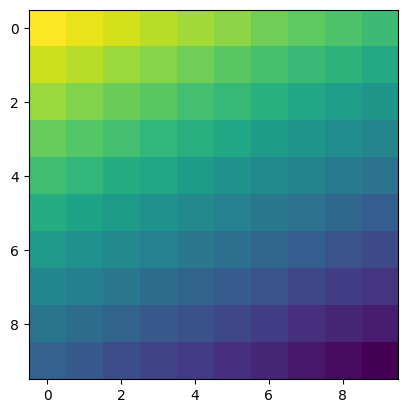

In [81]:
plt.imshow(DepthNormalizer()(transforms.ToTensor()(depth))[0].numpy()[-10:, :10])

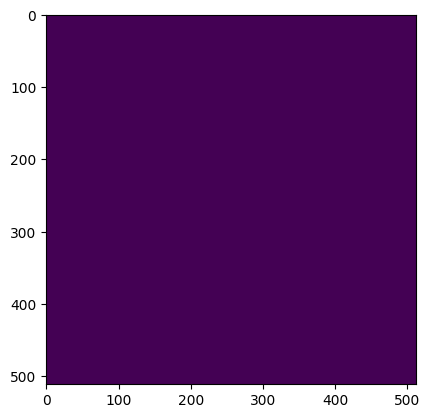

In [66]:
plt.imshow((torch.ones(512,512) * 25778).numpy())

In [21]:
transforms.ToTensor()(semantic).numpy()[0][:10, :10]

array([[25922, 25918, 25913, 25909, 25904, 25900, 25895, 25891, 25887,
        25883],
       [25911, 25907, 25902, 25898, 25893, 25889, 25884, 25880, 25876,
        25872],
       [25900, 25896, 25891, 25887, 25882, 25878, 25873, 25869, 25865,
        25860],
       [25889, 25884, 25880, 25875, 25871, 25866, 25862, 25857, 25853,
        25849],
       [25877, 25873, 25868, 25864, 25859, 25855, 25850, 25846, 25841,
        25837],
       [25866, 25861, 25857, 25852, 25848, 25843, 25839, 25834, 25830,
        25826],
       [25854, 25850, 25845, 25840, 25836, 25831, 25827, 25822, 25818,
        25814],
       [25842, 25838, 25833, 25828, 25824, 25819, 25815, 25810, 25806,
        25802],
       [25831, 25826, 25821, 25817, 25812, 25807, 25803, 25798, 25794,
        25790],
       [25819, 25814, 25809, 25805, 25800, 25795, 25791, 25786, 25782,
        25778]], dtype=int32)

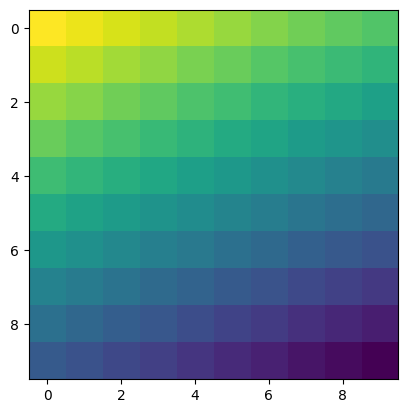

In [20]:
plt.imshow(transforms.ToTensor()(semantic).numpy()[0][:10, :10])

In [44]:
sem_tens = transforms.PILToTensor()(semantic)

In [46]:
rotator(sem_tens)

tensor([[[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]]], dtype=torch.uint8)

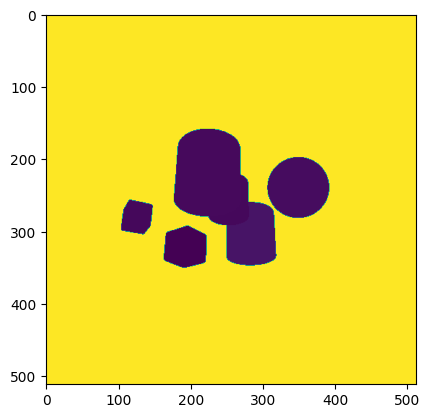

In [82]:
plt.imshow(vertical(sem_tens).numpy()[0])

In [53]:
transforms.ToTensor()(rgb).max(), transforms.ToTensor()(rgb).min()

(tensor(1.), tensor(0.0235))

In [56]:
torch.tensor([23.01586477, 22.23779258, 22.15062455]) / torch.tensor(255)

tensor([0.0903, 0.0872, 0.0869])

In [21]:
rgb = Image.open('/home/data/dq/clevr_complex/train/rgb/1003_0.png').convert('RGB')

tens_rgb = transforms.ToTensor()(rgb)
mrgb = transforms.Normalize(
                    mean=[0.4753, 0.4713, 0.4645],
                    std=[0.0903, 0.0872, 0.0869],
)(tens_rgb)

In [23]:
mrgb.max(), mrgb.min(), tens_rgb.max(), tens_rgb.min()

(tensor(6.1623), tensor(-5.1350), tensor(1.), tensor(0.0235))

In [32]:
tens_rgb.flatten()[616677]

tensor(1.)

In [35]:
(0. - 0.4645) / 0.0869

-5.345224395857307

In [42]:
mrgb.max(), mrgb.max()

(tensor(-5.2222), tensor(-5.2222))

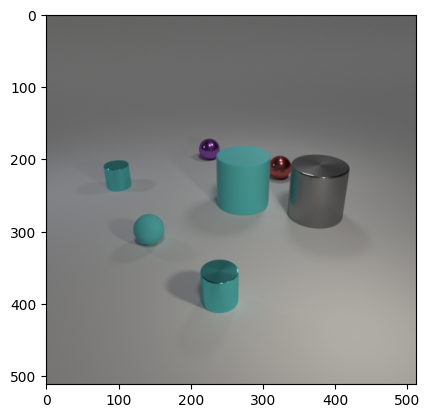

In [43]:
plt.imshow(transforms.ToTensor()(rgb).permute(1,2,0).numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


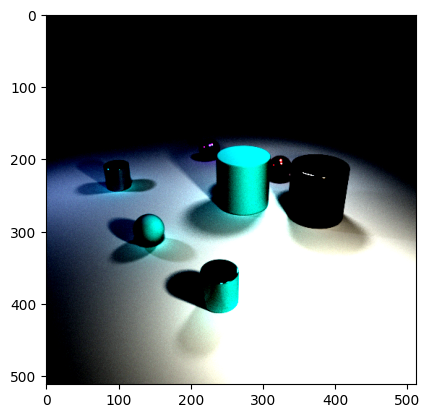

In [63]:
plt.imshow(mrgb.permute(1,2,0).numpy())

In [20]:
transforms.Resize((4, 4), interpolation=transforms.InterpolationMode.NEAREST)(sem_tens)

tensor([[[255, 255, 255, 255],
         [255, 255, 255, 255],
         [255, 255,  10,  12],
         [255, 255, 255, 255]]], dtype=torch.uint8)

In [83]:
depth = Image.open('/home/data/dq/clevr_complex/train/depth/1002_0.png')

In [88]:
d = transforms.ToTensor()(depth)

In [90]:
d.float() / (2**15 - 1.0)

tensor([[[0.7911, 0.7910, 0.7908,  ..., 0.9902, 0.9912, 0.9923],
         [0.7908, 0.7906, 0.7905,  ..., 0.9897, 0.9908, 0.9918],
         [0.7904, 0.7903, 0.7902,  ..., 0.9892, 0.9902, 0.9913],
         ...,
         [0.2274, 0.2273, 0.2271,  ..., 0.2271, 0.2273, 0.2274],
         [0.2271, 0.2270, 0.2269,  ..., 0.2269, 0.2270, 0.2271],
         [0.2268, 0.2267, 0.2266,  ..., 0.2266, 0.2267, 0.2268]]])

In [9]:
from transforms import MultiRandomRotate, MultiHorizontalFlip, MultiVerticalFlip, DepthNormalizer, LongTransform, FirstChannelTransform
from torchvision import transforms as transforms
from dataset import MultiModalDataset




train_transforms = {
    "rgb": transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.Normalize(
                mean=[0.4753, 0.4713, 0.4645],
                std=[0.0903, 0.0872, 0.0869],
            )
        ]
    ),
    "semseg": transforms.Compose(
        [
            transforms.PILToTensor(),
            transforms.Resize(
                (224, 224), interpolation=transforms.InterpolationMode.NEAREST
            ),
            FirstChannelTransform(),
            LongTransform(),
        ]
    ),
}
target_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Resize((224, 224)), DepthNormalizer()]
)

multimodal_transforms = [
        MultiHorizontalFlip(0.5),
        MultiVerticalFlip(0.5),
        MultiRandomRotate(0.5, 90)
    ]

### MAKE DATASETS ###
in_domains = ['rgb', 'semseg']
out_domains = ['depth']

train_dataset = MultiModalDataset(
    root_dir="../../../data/dq/clevr_complex/train",
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=target_transform,
    multimodal_augmentations=multimodal_transforms,
    training=True
)

In [39]:
sample_dict, y = train_dataset[0]

In [18]:
sample_dict['rgb'].max()

tensor(6.1623)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


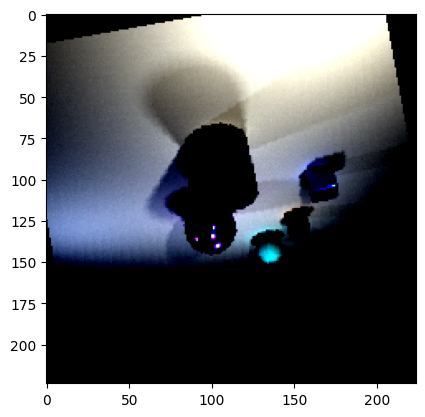

In [40]:
plt.imshow(sample_dict['rgb'].permute(1,2,0).numpy())

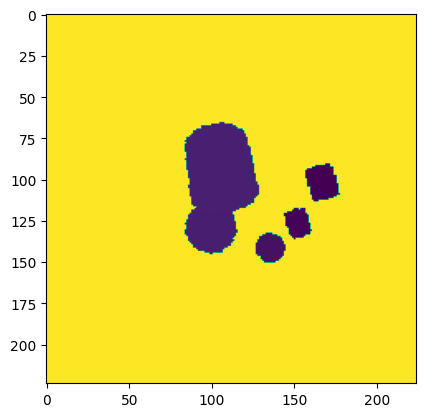

In [41]:
plt.imshow(sample_dict['semseg'].numpy())

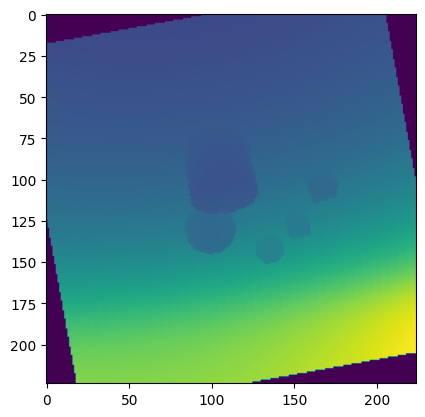

In [42]:
plt.imshow(y[0].numpy())

In [5]:
sample_dict = {'r': 1, 'b': 2}

augments = [lambda x: x*2, lambda x: x + 1]

for aug in augments:
    for t, v in sample_dict.items():
        sample_dict[t] = aug(v)
        

In [6]:
sample_dict

{'r': 3, 'b': 5}

In [22]:
from PIL import Image
import numpy as np
import os

def calculate_image_statistics(image_path):
    # Read the image
    image = Image.open(image_path)
    image_np = np.array(image)

    # Calculate width and height
    width, height = image.size

    # Calculate pixel intensity for each channel
    if image_np.ndim == 3:
        pixel_intensity = np.mean(image_np, axis=(0, 1))
    else:
        pixel_intensity = np.mean(image_np)

    # Calculate mean and std by channel
    if image_np.ndim == 3:
        mean_by_channel = np.mean(image_np, axis=(0, 1))
        std_by_channel = np.std(image_np, axis=(0, 1))
    else:
        mean_by_channel = np.mean(image_np)
        std_by_channel = np.std(image_np)

    # # Assess image quality (using blur as a proxy)
    # gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
    # laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    return {
        "width": width,
        "height": height,
        "pixel_intensity": pixel_intensity,
        "mean_by_channel": mean_by_channel,
        "std_by_channel": std_by_channel,
      #  "quality (blur)": laplacian_var
    }

def main(directory_path):
    statistics = []
    for filename in tqdm(os.listdir(directory_path)[:5000]):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(directory_path, filename)
            stats = calculate_image_statistics(image_path)
            statistics.append(stats)
    
    return statistics

# Replace 'your_image_directory_path' with the path of your image dataset
directory_path = '/home/data/dq/clevr_complex/train/rgb/'
image_stats = main(directory_path)

# Process image_stats as needed, e.g., calculate averages, distributions, etc.


  0%|          | 0/5000 [00:00<?, ?it/s]

 24%|██▍       | 1215/5000 [00:45<02:21, 26.71it/s]


KeyboardInterrupt: 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'image_stats' is your list of dictionaries containing image statistics


# Convert the list of dictionaries to a pandas DataFrame for easier analysis
df = pd.DataFrame(image_stats)

# Calculate means
#means = df.mean()

In [4]:
df

,width,height,pixel_intensity,mean_by_channel,std_by_channel
0,512,512,"[121.39017868041992, 121.84901809692383, 119.0...","[121.39017868041992, 121.84901809692383, 119.0...","[31.89049882382786, 29.120383705500508, 29.615..."
1,512,512,"[127.15541076660156, 125.49445724487305, 125.0...","[127.15541076660156, 125.49445724487305, 125.0...","[19.796807997599398, 20.501369332575027, 17.48..."
2,512,512,"[117.44232177734375, 115.47266006469727, 113.1...","[117.44232177734375, 115.47266006469727, 113.1...","[23.267810349852887, 24.518598546982634, 25.99..."
3,512,512,"[113.59258651733398, 110.6074104309082, 115.80...","[113.59258651733398, 110.6074104309082, 115.80...","[29.917288427381685, 28.799300649277797, 20.43..."
4,512,512,"[126.16997528076172, 122.34630584716797, 121.9...","[126.16997528076172, 122.34630584716797, 121.9...","[26.632925957537868, 28.840053906717483, 26.17..."
...,...,...,...,...,...
995,512,512,"[121.05531692504883, 120.58419799804688, 118.2...","[121.05531692504883, 120.58419799804688, 118.2...","[17.690400641194923, 16.268042256007345, 18.11..."
996,512,512,"[123.45098114013672, 123.49834060668945, 120.9...","[123.45098114013672, 123.49834060668945, 120.9...","[22.821887959801604, 19.605825523681773, 21.57..."
997,512,512,"[126.95632934570312, 124.62283325195312, 123.6...","[126.95632934570312, 124.62283325195312, 123.6...","[22.94600194029476, 23.902928081973865, 22.061..."
998,512,512,"[120.56935119628906, 122.0191764831543, 117.43...","[120.56935119628906, 122.0191764831543, 117.43...","[31.519141493689755, 28.00984486113291, 30.131..."


In [9]:
np.vstack(df['std_by_channel'].values).mean(axis=0)

array([22.98711599, 22.20778617, 22.16254607,  0.        ])

In [12]:
df['pixel_intensity'] = df['pixel_intensity'].apply(lambda x: x[:3])

In [19]:
data = np.vstack(df['pixel_intensity'].values)

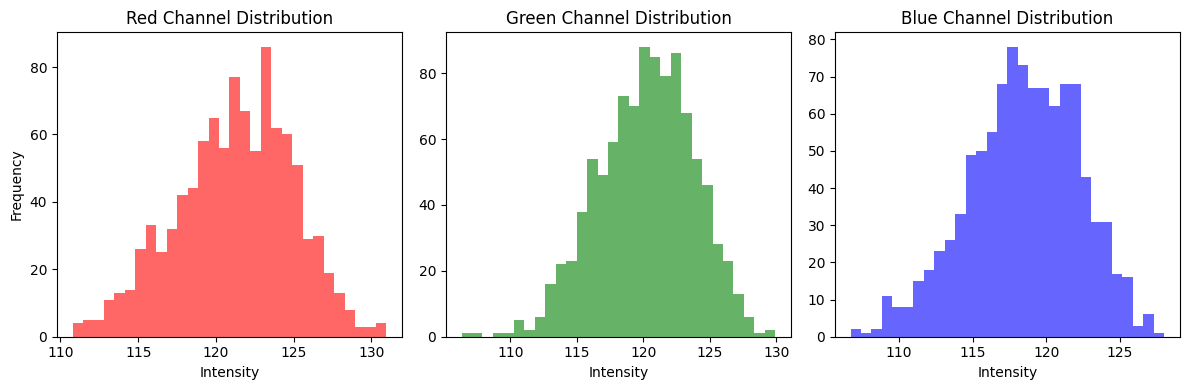

In [21]:
plt.figure(figsize=(12, 4))

# Plotting Red Channel
plt.subplot(1, 3, 1)
plt.hist(data[:, 0], bins=30, color='red', alpha=0.6)
plt.title('Red Channel Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

# Plotting Green Channel
plt.subplot(1, 3, 2)
plt.hist(data[:, 1], bins=30, color='green', alpha=0.6)
plt.title('Green Channel Distribution')
plt.xlabel('Intensity')

# Plotting Blue Channel
plt.subplot(1, 3, 3)
plt.hist(data[:, 2], bins=30, color='blue', alpha=0.6)
plt.title('Blue Channel Distribution')
plt.xlabel('Intensity')

plt.tight_layout()
plt.savefig('pixel_intensity.png')
plt.show()

ValueError: 'red' is not in list

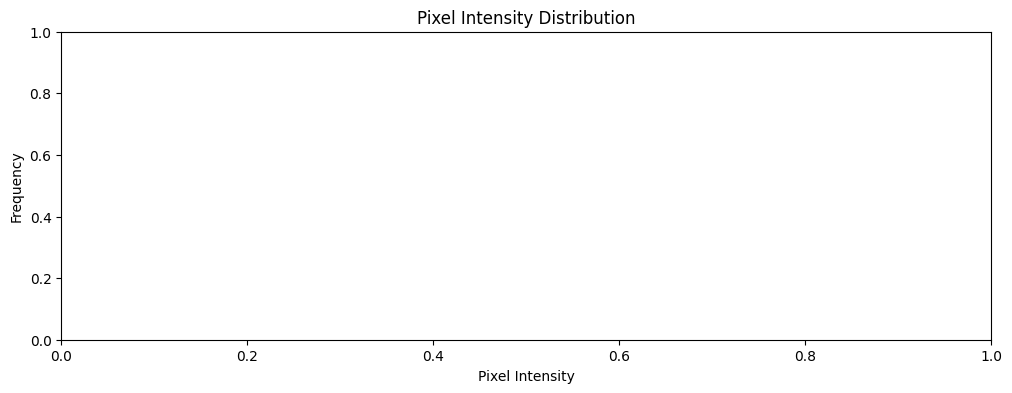

In [13]:
if 'pixel_intensity' in df.columns:
    plt.figure(figsize=(12, 4))
    plt.title('Pixel Intensity Distribution')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    for color, label in zip(['red', 'green', 'blue'], ['Red Channel', 'Green Channel', 'Blue Channel']):
        plt.hist(df['pixel_intensity'].apply(lambda x: x[list('rgb').index(color)]), 
                 bins=30, color=color, alpha=0.6, label=label)
    plt.legend()
    plt.show()

In [134]:
import os
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import Dataset


class MultiModalDataset(Dataset):
    def __init__(self, root_dir, train_transform=None, target_transofrm=None, input_tasks=['rgb'], output_task='depth'):
        self.root_dir = root_dir
        self.train_transform = train_transform
        self.target_transform = target_transofrm
        self.input_tasks = input_tasks
        self.output_task = output_task
        self.all_tasks = input_tasks + [output_task]
        for task_name in self.all_tasks:
            task_path = os.path.join(root_dir, task_name)
            self.__dict__[task_name+'_path'] = task_path
            self.__dict__[task_name+'_files'] = sorted(os.listdir(task_path))

    def __len__(self):
        task = self.all_tasks[0]
        return len(self.__dict__[task + '_files'])

    def __getitem__(self, idx):
        # obtain input object
        sample_dict = {}
        for task in self.input_tasks:
            file_name = self.__dict__[task+'_files'][idx]
            file_path = os.path.join(self.__dict__[task+'_path'], file_name)
            x = Image.open(file_path)
            if task == 'rgb':
                x = x.convert('RGB')
            if task == 'semantic':
                x = x.convert('L')
            
            if self.train_transform:
                x = self.train_transform[task](x)
            sample_dict[task] = x

        # obtain target
        target_file_name = self.__dict__[self.output_task+'_files'][idx]
        target_file_path = os.path.join(self.__dict__[self.output_task+'_path'], file_name)
        y = Image.open(target_file_path)

        assert file_name == target_file_name

        if self.target_transform:
            y = self.target_transform(y)

        return sample_dict, y


In [145]:
class FirstChannelTransform:
    def __init__(self):
        pass
    
    def __call__(self, x: torch.Tensor):
        return x[0]

class LongTransform:
    def __init__(self):
        pass
    
    def __call__(self, x: torch.Tensor):
        return x.long()

train_transforms = {
    'rgb': transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224))]),
    'semseg': transforms.Compose([transforms.PILToTensor(), transforms.Resize((224, 224)), FirstChannelTransform(), LongTransform()])
}

target_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224))])

In [146]:
# Create instances of the dataset for training and validation
train_dataset = MultiModalDataset(root_dir='../../../data/dq/clevr_complex/train/', input_tasks=['rgb', 'semseg'], output_task='depth',
                             train_transform=train_transforms, target_transofrm=target_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2)

In [147]:
len(train_dataset)

50000

In [148]:
for batch in train_loader:
    break

In [139]:
from functools import partial
from input_adapters import PatchedInputAdapter, SemSegInputAdapter

In [156]:
COCO_SEMSEG_NUM_CLASSES = 255

DOMAIN_CONF = {
    'rgb': {
        'channels': 3,
        'stride_level': 1,
        'input_adapter': partial(PatchedInputAdapter, num_channels=3),
        'aug_type': 'image',
    },
    'depth': {
        'channels': 1,
        'stride_level': 1,
        'input_adapter': partial(PatchedInputAdapter, num_channels=1),
        'aug_type': 'mask',
    },
    'mask_valid': {
        'stride_level': 1,
        'aug_type': 'mask',
    },
    'semseg': {
        'stride_level': 1,
        'aug_type': 'mask',
        'input_adapter': partial(SemSegInputAdapter, num_classes=COCO_SEMSEG_NUM_CLASSES,
                                 dim_class_emb=32, interpolate_class_emb=False,
                                 emb_padding_idx=COCO_SEMSEG_NUM_CLASSES),
    }
}


in_domains = ['rgb', 'semseg']
out_domains = ['depth']
all_domains = list(set(in_domains) | set(out_domains))

patch_size = 16
input_size = 224

input_adapters = {
        domain: DOMAIN_CONF[domain]['input_adapter'](
            stride_level=DOMAIN_CONF[domain]['stride_level'],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

In [157]:
from output_adapters import DPTOutputAdapter, ConvNeXtAdapter

decoder_main_tasks = ['rgb', 'semseg']

additional_targets = {domain: DOMAIN_CONF[domain]['aug_type'] for domain in all_domains}

# DPT settings are fixed for ViT-B. Modify them if using a different backbone.

adapters_dict = {
    'dpt': DPTOutputAdapter,
    'convnext': partial(ConvNeXtAdapter, preds_per_patch=64),
}

output_adapter = 'dpt'

output_adapters = {
    domain: adapters_dict[output_adapter](
        num_classes=DOMAIN_CONF[domain]['channels'],
        stride_level=DOMAIN_CONF[domain]['stride_level'],
        patch_size=patch_size,
        main_tasks=decoder_main_tasks
    )
    for domain in out_domains

}

In [158]:
from multimae import multivit_base

model_name = 'multivit_base'
drop_path_encoder = 0.0


In [159]:
model = multivit_base(input_adapters=input_adapters, output_adapters=output_adapters)

In [153]:
x = torch.rand(5, 3, 224, 224)
semseg = torch.rand(5, 224, 224).long()
#depth = torch.rand(5, 1, 224, 224)
sample_dict = {'rgb': x, 'semseg': semseg}
#tokens = torch.rand(5, 197, 768)

In [152]:
batch[0]['rgb'].size(), batch[0]['semseg'].size()

(torch.Size([2, 3, 224, 224]), torch.Size([2, 224, 224]))

In [160]:
out = model(batch[0], return_all_layers=True)

torch.Size([2, 196, 768])


In [25]:
out['depth'].size()

torch.Size([5, 1, 224, 224])

In [20]:
task_tokens['rgb'].size(), task_tokens['semseg'].size()

(torch.Size([5, 196, 768]), torch.Size([5, 196, 768]))

In [10]:
out['depth'].size()

torch.Size([5, 1, 224, 224])

In [14]:
def masked_berhu_loss(preds, target, mask_valid=None):
    if mask_valid is None:
        mask_valid = torch.ones_like(preds).bool()
    if preds.shape[1] != mask_valid.shape[1]:
        mask_valid = mask_valid.repeat_interleave(preds.shape[1], 1)

    diff = preds - target
    diff[~mask_valid] = 0
    with torch.no_grad():
        c = max(torch.abs(diff).max() * 0.2, 1e-5)

    l1_loss = torch.abs(diff)
    l2_loss = (torch.square(diff) + c**2) / 2. / c
    berhu_loss = l1_loss[torch.abs(diff) < c].sum() + l2_loss[torch.abs(diff) >= c].sum()

    return berhu_loss / mask_valid.sum()

@torch.no_grad()
def masked_metrics(preds, target, mask_valid=None):
    # map to the original scale 
    # preds = preds * NYU_STD + NYU_MEAN
    # target = target * NYU_STD + NYU_MEAN

    if mask_valid is None:
        mask_valid = torch.ones_like(preds).bool()
    if preds.shape[1] != mask_valid.shape[1]:
        mask_valid = mask_valid.repeat_interleave(preds.shape[1], 1)

    n = mask_valid.sum()
    
    diff = torch.abs(preds - target)
    diff[~mask_valid] = 0
    
    max_rel = torch.maximum(preds/torch.clamp_min(target, 1e-6), target/torch.clamp_min(preds, 1e-6))
    max_rel = max_rel[mask_valid]

    log_diff = torch.log(torch.clamp_min(preds, 1e-6)) - torch.log(torch.clamp_min(target, 1e-6))
    log_diff[~mask_valid] = 0

    metrics = {
        'rmse': (diff.square().sum() / n).sqrt(),
        'rel': (diff/torch.clamp_min(target, 1e-6))[mask_valid].mean(),
        'srel': (diff**2/torch.clamp_min(target, 1e-6))[mask_valid].mean(),
        'log10': (log_diff.square().sum() / n).sqrt(),
        'delta_1': (max_rel < 1.25).float().mean(),
        'delta_2': (max_rel < (1.25**2)).float().mean(),
        'delta_3': (max_rel < (1.25**3)).float().mean(),
    }
    return metrics

In [15]:
loss = masked_berhu_loss(preds=out['depth'], target=depth)

In [17]:
loss.backward()

In [16]:
metrics = masked_metrics(preds=out['depth'], target=depth)

In [17]:
metrics

{'rmse': tensor(0.5789),
 'rel': tensor(1.0782),
 'srel': tensor(0.5048),
 'log10': tensor(10.3892),
 'delta_1': tensor(0.0010),
 'delta_2': tensor(0.0021),
 'delta_3': tensor(0.0033)}

In [18]:
from pos_embed_multi import interpolate_pos_embed_multimae


finetune_path = './data/mae-b_dec512d8b_1600e_multivit-c477195b.pth'
checkpoint = torch.load(finetune_path, map_location='cpu')

checkpoint_model = checkpoint['model']

# # Remove keys for semantic segmentation
# for k in list(checkpoint_model.keys()):
#     if "semseg" in k:
#         del checkpoint_model[k]


# Remove output adapters
for k in list(checkpoint_model.keys()):
    if "output_adapters" in k:
        del checkpoint_model[k]


# Interpolate position embedding
interpolate_pos_embed_multimae(model, checkpoint_model)

# Load pre-trained model
msg = model.load_state_dict(checkpoint_model, strict=False)
print(msg)

_IncompatibleKeys(missing_keys=['output_adapters.depth.scratch.layer1_rn.weight', 'output_adapters.depth.scratch.layer2_rn.weight', 'output_adapters.depth.scratch.layer3_rn.weight', 'output_adapters.depth.scratch.layer4_rn.weight', 'output_adapters.depth.scratch.layer_rn.0.weight', 'output_adapters.depth.scratch.layer_rn.1.weight', 'output_adapters.depth.scratch.layer_rn.2.weight', 'output_adapters.depth.scratch.layer_rn.3.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit2.conv1.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit2.conv1.bias', 'output_adapters.depth.scratch.r

In [34]:
set(checkpoint_model.keys()) & set(model.state_dict().keys())

{'encoder.0.attn.proj.bias',
 'encoder.0.attn.proj.weight',
 'encoder.0.attn.qkv.bias',
 'encoder.0.attn.qkv.weight',
 'encoder.0.mlp.fc1.bias',
 'encoder.0.mlp.fc1.weight',
 'encoder.0.mlp.fc2.bias',
 'encoder.0.mlp.fc2.weight',
 'encoder.0.norm1.bias',
 'encoder.0.norm1.weight',
 'encoder.0.norm2.bias',
 'encoder.0.norm2.weight',
 'encoder.1.attn.proj.bias',
 'encoder.1.attn.proj.weight',
 'encoder.1.attn.qkv.bias',
 'encoder.1.attn.qkv.weight',
 'encoder.1.mlp.fc1.bias',
 'encoder.1.mlp.fc1.weight',
 'encoder.1.mlp.fc2.bias',
 'encoder.1.mlp.fc2.weight',
 'encoder.1.norm1.bias',
 'encoder.1.norm1.weight',
 'encoder.1.norm2.bias',
 'encoder.1.norm2.weight',
 'encoder.10.attn.proj.bias',
 'encoder.10.attn.proj.weight',
 'encoder.10.attn.qkv.bias',
 'encoder.10.attn.qkv.weight',
 'encoder.10.mlp.fc1.bias',
 'encoder.10.mlp.fc1.weight',
 'encoder.10.mlp.fc2.bias',
 'encoder.10.mlp.fc2.weight',
 'encoder.10.norm1.bias',
 'encoder.10.norm1.weight',
 'encoder.10.norm2.bias',
 'encoder.10.n

In [3]:

# Create DataLoader instances for training and validation
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:

model = create_model(
        model_name,
        input_adapters=input_adapters,
        output_adapters=output_adapters,
        drop_path_rate=drop_path_encoder,
)

In [ ]:
class MultiMAE(nn.Module):
    '''
    MultiMAE: Multi-task Multi-modal Masked Autoencoder
    This module performs masking in its forward pass.
    The MultiViT module defined below inherits from this module and performs a regular forward pass,
    and should be used instead for downstream tasks


    :param input_adapters: Dictionary of task -> input adapters
    :param output_adapters: Optional dictionary of task -> output adapters

    :param num_global_tokens: Number of additional global tokens to add (like cls tokens), default is 1
    :param dim_tokens: Dimension of encoder tokens
    :param depth: Depth of encoder
    :param num_heads: Number of attention heads
    :param mlp_ratio: MLP hidden dim ratio
    :param qkv_bias: Set to False to disable bias
    :param drop_rate: Dropout after MLPs and Attention
    :param attn_drop_rate: Attention matrix drop rate
    :param drop_path_rate: DropPath drop rate
    :param norm_layer: Type of normalization layer
    '''
    def __init__(self,
                 input_adapters: Dict[str, nn.Module],
                 output_adapters: Optional[Dict[str, nn.Module]],
                 num_global_tokens: int = 1,
                 dim_tokens: int = 768,
                 depth: int = 12,
                 num_heads: int = 12,
                 mlp_ratio: float = 4.0,
                 qkv_bias: bool = True,
                 drop_rate: float = 0.0,
                 attn_drop_rate: float = 0.0,
                 drop_path_rate: float = 0.0,
                 norm_layer: nn.Module = partial(nn.LayerNorm, eps=1e-6)):
        super().__init__()

        # Initialize input and output adapters
        for adapter in input_adapters.values():
            adapter.init(dim_tokens=dim_tokens)
        self.input_adapters = nn.ModuleDict(input_adapters)
        if output_adapters is not None:
            for adapter in output_adapters.values():
                adapter.init(dim_tokens_enc=dim_tokens)
            self.output_adapters = nn.ModuleDict(output_adapters)
        else:
            self.output_adapters = None

        # Additional learnable tokens that can be used by encoder to process/store global information
        self.num_global_tokens = num_global_tokens
        self.global_tokens = nn.Parameter(torch.zeros(1, num_global_tokens, dim_tokens))
        trunc_normal_(self.global_tokens, std=0.02)
        
        # Transformer encoder
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]  # stochastic depth decay rule
        self.encoder = nn.Sequential(*[
            Block(dim=dim_tokens, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                  drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[i], norm_layer=norm_layer)
            for i in range(depth)
        ])
        
        self.apply(self._init_weights)
        for name, m in self.named_modules():
            if isinstance(m, nn.Linear):
                if 'qkv' in name:
                    # treat the weights of Q, K, V separately
                    val = math.sqrt(6. / float(m.weight.shape[0] // 3 + m.weight.shape[1]))
                    nn.init.uniform_(m.weight, -val, val)
                elif 'kv' in name:
                    # treat the weights of K, V separately
                    val = math.sqrt(6. / float(m.weight.shape[0] // 2 + m.weight.shape[1]))
                    nn.init.uniform_(m.weight, -val, val)

            if isinstance(m, nn.Conv2d):
                if '.proj' in name:
                    # From MAE, initialize projection like nn.Linear (instead of nn.Conv2d)
                    w = m.weight.data
                    nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def get_num_layers(self):
        return len(self.encoder)

    @torch.jit.ignore
    def no_weight_decay(self):
        no_wd_set = {'global_tokens'}

        for task, adapter in self.input_adapters.items():
            if hasattr(adapter, 'no_weight_decay'):
                to_skip = adapter.no_weight_decay()
                to_skip = set([f'input_adapters.{task}.{name}' for name in to_skip])
                no_wd_set = no_wd_set | to_skip

        for task, adapter in self.output_adapters.items():
            if hasattr(adapter, 'no_weight_decay'):
                to_skip = adapter.no_weight_decay()
                to_skip = set([f'output_adapters.{task}.{name}' for name in to_skip])
                no_wd_set = no_wd_set | to_skip

        return no_wd_set

    def sample_alphas(self, B: int, n_tasks: int, alphas: float = 1.0, eps: float = 1e-5):
        """
        Sample alphas for Dirichlet sampling such that tasks are first uniformly chosen and then Dirichlet sampling
        is performed over the chosen ones.

        :param B: Batch size
        :param n_tasks: Number of input tasks
        :param alphas: Float or list to multiply task choices {0,1} by
        :param eps: Small constant since Dirichlet alphas need to be positive
        """
        valid_task_choices = torch.Tensor([list(i) for i in itertools.product([0, 1], repeat=n_tasks)][1:])
        rand_per_sample_choice = torch.randint(0, len(valid_task_choices), (B,))
        alphas_tensor = torch.index_select(valid_task_choices, 0, rand_per_sample_choice)
        alphas_tensor = alphas_tensor * torch.tensor(alphas) + eps
        return alphas_tensor

    def generate_random_masks(self,
                            input_tokens: Dict[str, torch.Tensor],
                            num_encoded_tokens: int,
                            alphas: Union[float, List[float]] = 1.0,
                            sample_tasks_uniformly: bool = False) :
        """
        Sample a total of num_encoded_tokens from different tasks using Dirichlet sampling.

        :param input_tokens: Dictionary of tensors to sample num_encoded_tokens from
        :param num_encoded_tokens: Number of tokens to select
        :param alphas: Dirichlet distribution parameter alpha. Lower alpha = harder,
            less uniform sampling. Can be float or list of floats.
        :param sample_tasks_uniformly: Set to True to first sample 1-n_tasks uniformly at random
            for each sample in the batch. Dirichlet sampling is then done over selected subsets.
        """
        B = list(input_tokens.values())[0].shape[0]
        device = list(input_tokens.values())[0].device

        alphas = [alphas] * len(input_tokens) if isinstance(alphas, float) else alphas
        if sample_tasks_uniformly:
            alphas = self.sample_alphas(B, len(input_tokens), alphas=alphas)
            task_sampling_dist = Dirichlet(alphas).sample().to(device)
        else:
            task_sampling_dist = Dirichlet(torch.Tensor(alphas)).sample((B,)).to(device)

        samples_per_task = (task_sampling_dist * num_encoded_tokens).round().long()

        task_masks = []
        num_tokens_per_task = [task_tokens.shape[1] for task_tokens in input_tokens.values()]
        for i, num_tokens in enumerate(num_tokens_per_task):
            # Use noise to shuffle arange
            noise = torch.rand(B, num_tokens, device=device)  # noise in [0, 1]
            ids_arange_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
            mask = torch.arange(num_tokens, device=device).unsqueeze(0).expand(B, -1)
            mask = torch.gather(mask, dim=1, index=ids_arange_shuffle)
            # 0 is keep (unmasked), 1 is remove (masked)
            mask = torch.where(mask < samples_per_task[:, i].unsqueeze(1), 0, 1)
            task_masks.append(mask)

        mask_all = torch.cat(task_masks, dim=1)
        ids_shuffle = torch.argsort(mask_all + torch.rand_like(mask_all.float()), dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :num_encoded_tokens]

        # Update binary mask to adjust for task rounding
        mask_all = torch.ones_like(mask_all)
        mask_all[:, :num_encoded_tokens] = 0
        # Unshuffle to get the binary mask
        mask_all = torch.gather(mask_all, dim=1, index=ids_restore)
        # Split to get task masks
        task_masks = torch.split(mask_all, num_tokens_per_task, dim=1)
        # Convert to dict
        task_masks = {domain: mask for domain, mask in zip(input_tokens.keys(), task_masks)}

        return task_masks, ids_keep, ids_restore

    @staticmethod
    def make_mask(N_H, N_W, xy_idxs, full_tasks=[], indicate_visible=True, flatten=True, device='cuda'):
        """
        Creates masks for each task, given lists of un-masked x,y coordinates.
        """
        xy_idxs = {
            k: torch.LongTensor(v)
            for k, v in xy_idxs.items()
        }

        task_masks = {
            k: torch.ones(N_H, N_W).to(device)
            for k in xy_idxs.keys()
        }

        for k in xy_idxs.keys():
            if len(xy_idxs[k]) > 0:
                task_masks[k][xy_idxs[k][:, 1], xy_idxs[k][:, 0]] = 0

        for task in full_tasks:
            task_masks[task][:] = 0

        if not indicate_visible:
            task_masks = {k: 1 - v for k, v in task_masks.items()}

        if flatten:
            task_masks = {k: v.flatten().unsqueeze(0) for k, v in task_masks.items()}

        return task_masks

    def generate_input_info(self, input_task_tokens, image_size):
        input_info = OrderedDict()
        i = 0
        input_info['tasks'] = {}
        for domain, tensor in input_task_tokens.items():
            num_tokens = tensor.shape[1]
            d = {
                'num_tokens': num_tokens,
                'has_2d_posemb': True,  # TODO: Modify when adding non-2D tasks
                'start_idx': i,
                'end_idx': i + num_tokens,
            }
            i += num_tokens
            input_info['tasks'][domain] = d

        input_info['image_size'] = image_size
        input_info['num_task_tokens'] = i
        input_info['num_global_tokens'] = self.num_global_tokens

        return input_info

    def forward(self, 
                x: Union[Dict[str, torch.Tensor], torch.Tensor], 
                mask_inputs: bool = True,
                task_masks: Dict[str, torch.Tensor] = None,
                num_encoded_tokens: int = 128,
                alphas: Union[float, List[float]] = 1.0,
                sample_tasks_uniformly: bool = False,
                fp32_output_adapters: List[str] = []):
        """
        Forward pass through input adapters, transformer encoder and output adapters.
        If specified, will randomly drop input tokens.

        :param x: Input tensor or dictionary of tensors
        :param mask_inputs: Set to True to enable random masking of input patches
        :param task_masks: Optional dictionary of task->mask pairs.
        :param num_encoded_tokens: Number of tokens to randomly select for encoder.
            Only used if mask_inputs is True.
        :param alphas: Dirichlet distribution parameter alpha for task sampling.
            Higher alpha = harder, less uniform sampling. Can be float or list of floats.
        :param sample_tasks_uniformly: Set to True if tasks should be uniformly presampled,
            before Dirichlet sampling decides share of masked tokens between them.
        :param fp32_output_adapters: List of task identifiers to force output adapters to
            run with mixed precision turned off for stability reasons.
        """

        ## Processing input modalities
        # If input x is a Tensor, assume it's RGB
        x = {'rgb': x} if isinstance(x, torch.Tensor) else x

        # Need image size for tokens->image reconstruction
        # We assume that at least one of rgb or semseg is given as input before masking
        if 'rgb' in x:
            B, C, H, W = x['rgb'].shape
        elif 'semseg' in x:
            B, H, W = x['semseg'].shape
            H *= self.input_adapters['semseg'].stride_level
            W *= self.input_adapters['semseg'].stride_level
        else:
            B, C, H, W = list(x.values())[0].shape  # TODO: Deal with case where not all have same shape

        # Encode selected inputs to tokens
        input_task_tokens = {
            domain: self.input_adapters[domain](tensor)
            for domain, tensor in x.items()
            if domain in self.input_adapters
        }

        input_info = self.generate_input_info(input_task_tokens=input_task_tokens, image_size=(H, W))

        # Select random subset of tokens from the chosen input tasks and concatenate them
        if mask_inputs:
            num_encoded_tokens = num_encoded_tokens if num_encoded_tokens is not None else self.num_encoded_tokens
        else:
            num_encoded_tokens = sum([tensor.shape[1] for tensor in input_task_tokens.values()])

        ## Generating masks
        if task_masks is None:
            task_masks, ids_keep, ids_restore = self.generate_random_masks(
                input_task_tokens,
                num_encoded_tokens,
                alphas=alphas,
                sample_tasks_uniformly=sample_tasks_uniformly
            )
        else:
            mask_all = torch.cat([task_masks[task] for task in input_task_tokens.keys()], dim=1)
            ids_shuffle = torch.argsort(mask_all, dim=1)
            ids_restore = torch.argsort(ids_shuffle, dim=1)
            ids_keep = ids_shuffle[:, :(mask_all == 0).sum()]

        input_tokens = torch.cat([task_tokens for task_tokens in input_task_tokens.values()], dim=1)

        # Apply mask
        input_tokens = torch.gather(input_tokens, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, input_tokens.shape[2]))

        # Add global tokens to input tokens
        global_tokens = repeat(self.global_tokens, '() n d -> b n d', b=B)
        input_tokens = torch.cat([input_tokens, global_tokens], dim=1)

        ## Transformer forward pass
        encoder_tokens = self.encoder(input_tokens)

        ## Output decoders
        if self.output_adapters is None:
            return encoder_tokens, task_masks

        # Decode tokens for each task using task-specific output adapters
        preds = {
            domain: self.output_adapters[domain](
                encoder_tokens=encoder_tokens,
                input_info=input_info,
                ids_keep=ids_keep,
                ids_restore=ids_restore,
            )
            for domain in self.output_adapters
            if domain not in fp32_output_adapters
        }
        # Force running selected output adapters in fp32 mode
        with torch.cuda.amp.autocast(enabled=False):
            for domain in fp32_output_adapters:
                if domain not in self.output_adapters:
                    continue
                preds[domain] = self.output_adapters[domain](
                    encoder_tokens=encoder_tokens.float(),
                    input_info=input_info,
                    ids_keep=ids_keep,
                    ids_restore=ids_restore,
                )
        
        return preds, task_masks


class MultiViT(MultiMAE):
    """
    MultiViT: Multi-modal Vision Transformer
    This is MultiMAE without masking and with a simplified / faster forward pass


    :param input_adapters: Dictionary of task -> input adapters
    :param output_adapters: Optional dictionary of task -> output adapters

    :param num_global_tokens: Number of additional global tokens to add (like cls tokens), default is 1
    :param dim_tokens: Dimension of encoder tokens
    :param depth: Depth of encoder
    :param num_heads: Number of attention heads
    :param mlp_ratio: MLP hidden dim ratio
    :param qkv_bias: Set to False to disable bias
    :param drop_rate: Dropout after MLPs and Attention
    :param attn_drop_rate: Attention matrix drop rate
    :param drop_path_rate: DropPath drop rate
    :param norm_layer: Type of normalization layer
    """

    def process_input(self, x):

        # If input x is a Tensor, assume it's RGB
        x = {'rgb': x} if isinstance(x, torch.Tensor) else x
        # Need image size for tokens->image reconstruction
        if 'rgb' in x:
            B, _, H, W = x['rgb'].shape
        elif 'semseg' in x:
            B, H, W = x['semseg'].shape
            H *= self.input_adapters['semseg'].stride_level
            W *= self.input_adapters['semseg'].stride_level
        else:
            B, _, H, W = list(x.values())[0].shape  # TODO: Deal with case where not all have same shape

        # Encode selected inputs to tokens
        input_task_tokens = {
            domain: self.input_adapters[domain](tensor)
            for domain, tensor in x.items()
            if domain in self.input_adapters
        }

        input_info = self.generate_input_info(input_task_tokens=input_task_tokens, image_size=(H, W))
        input_tokens = torch.cat([task_tokens for task_tokens in input_task_tokens.values()], dim=1)

        # Add global tokens to input tokens
        global_tokens = repeat(self.global_tokens, '() n d -> b n d', b=B)
        input_tokens = torch.cat([input_tokens, global_tokens], dim=1)

        return input_tokens, input_info

    def forward(self, x: Union[Dict[str, torch.Tensor], torch.Tensor], return_all_layers=False, **kwargs):
        """
        Forward pass through input adapters, transformer encoder and output adapters.

        :param x: Input tensor or dictionary of tensors
        :param return_all_layers: Set to True to return all transformer layers
        """

        input_tokens, input_info = self.process_input(x)

        # Pass tokens through Transformer
        if not return_all_layers:
            encoder_tokens = self.encoder(input_tokens)
        else:
            # Optionally access every intermediate layer
            encoder_tokens = []
            tokens = input_tokens
            for block in self.encoder:
                tokens = block(tokens)
                encoder_tokens.append(tokens)

        if self.output_adapters is None:
            return encoder_tokens

        # Decode tokens for each task using task-specific output adapters
        preds = {
            domain: self.output_adapters[domain](
                encoder_tokens=encoder_tokens,
                input_info=input_info,
            )
            for domain in self.output_adapters
        }

        return preds


def multivit_base(
        input_adapters: Dict[str, nn.Module],
        output_adapters: Optional[Dict[str, nn.Module]],
        **kwargs):
    model = MultiViT(
        input_adapters=input_adapters,
        output_adapters=output_adapters,
        dim_tokens=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4,
        qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6),
        **kwargs
    )
    return model

In [24]:
import shutil

def rearrange_directories(root_path, subset):
    source_rgb = os.path.join(root_path, 'rgb', 'clevr_complex', subset)
    source_depth = os.path.join(root_path, 'depth_euclidean', 'clevr_complex', subset)

    destination_root = os.path.join(root_path, 'clevr_complex', subset)
    destination_rgb = os.path.join(destination_root, 'rgb')
    destination_depth = os.path.join(destination_root, 'depth_euclidean')

    # Create destination directories if they don't exist
    os.makedirs(destination_root, exist_ok=True)
    os.makedirs(destination_rgb, exist_ok=True)
    os.makedirs(destination_depth, exist_ok=True)

    # Move and rename directories
    shutil.move(source_rgb, destination_rgb)
    shutil.move(source_depth, destination_depth)

# root = './data'
# subset = 'test'
# rearrange_directories(root, subset)


def rename(root_dir):
    import os
    import re

    
    splits = ["train", "val", "test"]
    domains = ["rgb", "depth_euclidean"]

    for split in splits:
        for domain in domains:
            dir_path = os.path.join(root_dir, split, domain)

            for filename in os.listdir(dir_path):
                match = re.match(r'point_(\d+)_view_(\d+)_domain_(.+)\.png', filename)
                if match:
                    new_name = f"{match.group(1)}_{match.group(2)}.png"
                    old_path = os.path.join(dir_path, filename)
                    new_path = os.path.join(dir_path, new_name)

                    os.rename(old_path, new_path)

    print("Files renamed successfully.")

# root_dir = './data/clevr_complex/'
# rename(root_dir)